Accuracy: 100.00%


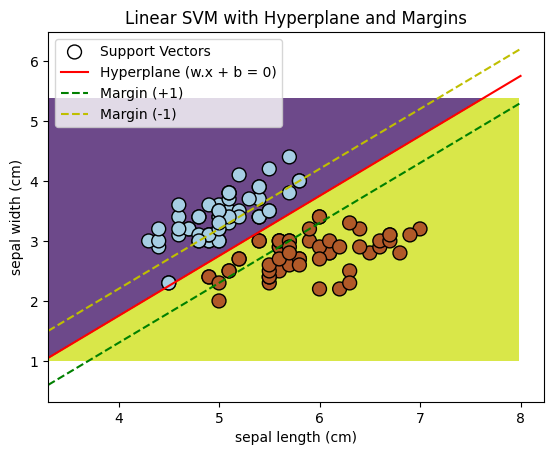

In [30]:
# Import necessary libraries
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np

# Load the dataset (Iris dataset for example)
iris = datasets.load_iris()
X = iris.data[:, :2]  # Select only the first two features for easy visualization
y = iris.target

# We only want two classes for linear SVM, so we filter out class 2
X = X[y != 2]
y = y[y != 2]

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create a linear SVM classifier
svm = SVC(kernel='linear')

# Train the model
svm.fit(X_train, y_train)

# Predict the labels for the test set
y_pred = svm.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

# Plot the decision boundary, hyperplane, and margin boundaries
h = .02  # Step size in the mesh
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

Z = svm.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plotting the decision boundary
plt.contourf(xx, yy, Z, alpha=0.8)

# Plot the margin boundaries (distance from the hyperplane)
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

# Support vectors
support_vectors = svm.support_vectors_
# Plotting the support vectors
plt.scatter(support_vectors[:, 0], support_vectors[:, 1], facecolors='none', edgecolors='k', s=100, label="Support Vectors")

# Plotting the hyperplane (decision boundary) and margins
w = svm.coef_[0]
b = svm.intercept_[0]

# Equation of the hyperplane: w.x + b = 0
# Plot the margin boundaries: w.x + b = 1 and w.x + b = -1
xx_line = np.linspace(x_min, x_max)
yy_line = (-w[0] * xx_line - b) / w[1]

# Plot the decision boundary (w.x + b = 0)
plt.plot(xx_line, yy_line, 'r-', label="Hyperplane (w.x + b = 0)")

# Plot the margin boundaries (w.x + b = 1 and w.x + b = -1)
yy_margin1 = (-w[0] * xx_line - (b - 1)) / w[1]
yy_margin2 = (-w[0] * xx_line - (b + 1)) / w[1]

plt.plot(xx_line, yy_margin1, 'g--', label="Margin (+1)")
plt.plot(xx_line, yy_margin2, 'y--', label="Margin (-1)")

# Plotting the data points
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', marker='o', s=100, cmap=plt.cm.Paired)

# Add labels and title
plt.title("Linear SVM with Hyperplane and Margins")
plt.xlabel("sepal length (cm)")
plt.ylabel("sepal width (cm)")
plt.legend(loc='best')
plt.show()

Accuracy: 43.33%


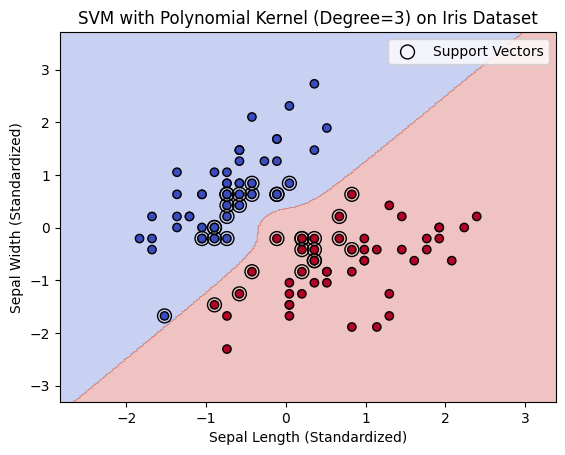

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Step 1: Load the Iris dataset
iris = datasets.load_iris()
X = iris.data[:, :2]  # Select first two features (sepal length and width)
y = iris.target

# Select only two classes (Setosa and Versicolor) for binary classification
X = X[y != 2]
y = y[y != 2]
y = np.where(y == 0, -1, 1)  # Convert labels to -1 and +1 for SVM

# Step 2: Feature Scaling
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Step 3: Train an SVM with a Polynomial Kernel
svm_poly = SVC(kernel='poly', degree=3, C=1.0)  # Using a degree=3 polynomial kernel
svm_poly.fit(X, y)
# Predict the labels for the test set
y_pred = svm_poly.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")
# Step 4: Plot the decision boundary
def plot_decision_boundary(X, y, model):
    h = 0.02  # Step size for mesh grid
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k')

    # Plot support vectors
    plt.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1], s=100,
                facecolors='none', edgecolors='black', label="Support Vectors")

    plt.xlabel("Sepal Length (Standardized)")
    plt.ylabel("Sepal Width (Standardized)")
    plt.title("SVM with Polynomial Kernel (Degree=3) on Iris Dataset")
    plt.legend()
    plt.show()

plot_decision_boundary(X, y, svm_poly)


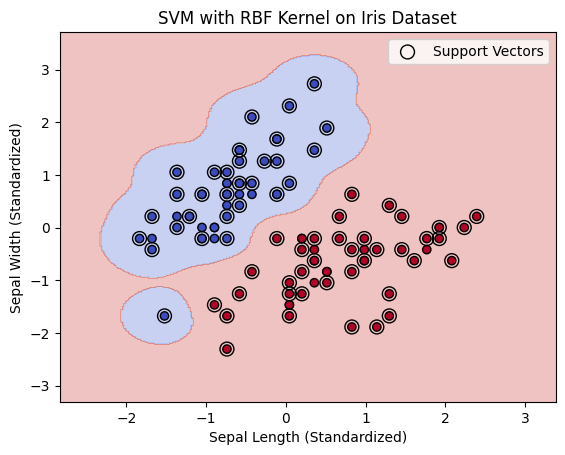

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# Step 1: Load the Iris dataset
iris = datasets.load_iris()
X = iris.data[:, :2]  # Select first two features (sepal length and width)
y = iris.target

# Select only two classes (Setosa and Versicolor) for binary classification
X = X[y != 2]
y = y[y != 2]
y = np.where(y == 0, -1, 1)  # Convert labels to -1 and +1 for SVM

# Step 2: Feature Scaling
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Step 3: Train an SVM with RBF Kernel
svm_rbf = SVC(kernel='rbf', gamma=8, C=1.0)  # Using gamma=0.5
svm_rbf.fit(X, y)

# Step 4: Plot the decision boundary
def plot_decision_boundary(X, y, model):
    h = 0.02  # Step size for mesh grid
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k')

    # Plot support vectors
    plt.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1], s=100,
                facecolors='none', edgecolors='black', label="Support Vectors")

    plt.xlabel("Sepal Length (Standardized)")
    plt.ylabel("Sepal Width (Standardized)")
    plt.title("SVM with RBF Kernel on Iris Dataset")
    plt.legend()
    plt.show()

plot_decision_boundary(X, y, svm_rbf)
